In [39]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import glob

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Fig1

In [40]:
data_dir = "/data/shared_data/ARM_data/ENA/enarlproffex1thorC1"

dates = ["20181122", ]   # change to the day you want

files = []
for d in dates:
    f = glob.glob(f"{data_dir}/enarlproffex1thorC1.c0.{d}*.nc")
    files.extend(f)

print(files)

if len(files) == 0:
    raise FileNotFoundError("No files found. Check date or filename pattern.")

# ds_a = xr.open_mfdataset(files, combine="by_coords")
ds_a = xr.open_mfdataset(
    files,
    combine="by_coords",
    compat="override"
)

['/data/shared_data/ARM_data/ENA/enarlproffex1thorC1/enarlproffex1thorC1.c0.20181122.000000.custom.nc']


In [41]:
# ===== parameters =====
hcoord = "height_high"
hmin_km, hmax_km = 0.03, 20.0

valid_classes = [3, 9, 21, 37]
aerosol_class = 3
cloud_class = 21

dep_m  = 0.0049
dep_d  = 0.31
dep_nd = 0.15
T_K_WARM = 273.15

ds_sub = ds_a.sel({hcoord: slice(hmin_km, hmax_km)})

# ===== QC =====
mask_qc = (
    (ds_sub["detection_confidence_score_total"] >= 0.3) &
    (ds_sub["qc_profile"] == 0)
)

feature_mask = ds_sub["feature_mask"].where(mask_qc)
pdr_meas     = ds_sub["depolarization_ratio"].where(mask_qc)
ext          = ds_sub["extinction_be"].where(mask_qc)
sca          = ds_sub["scattering_ratio_e"].where(mask_qc)
temp_qc      = ds_sub["temperature"].where(mask_qc)

# ===== keep valid classes =====
mask_class = xr.zeros_like(feature_mask, dtype=bool)
for val in valid_classes:
    mask_class = mask_class | (feature_mask == val)

feature_mask = feature_mask.where(mask_class)
pdr_meas     = pdr_meas.where(mask_class)
ext          = ext.where(mask_class)
sca          = sca.where(mask_class)
temp_qc      = temp_qc.where(mask_class)

# ===== aerosol extinction =====
aerosol_mask = feature_mask == aerosol_class

pdr_meas_aerosol = pdr_meas.where(aerosol_mask)
sca_aerosol      = sca.where(aerosol_mask)
ext_aerosol      = ext.where(aerosol_mask)

# ===== cloud extinction: warm cloud only =====
cloud_mask_warm = (feature_mask == cloud_class) & (temp_qc >= T_K_WARM)

ext_cloud = ext.where(cloud_mask_warm)
ext_cloud = ext_cloud.where(ext_cloud > 0)

# ===== calculate PDR =====
tepo = sca_aerosol + (sca_aerosol * dep_m) - dep_m
xnum = tepo * pdr_meas_aerosol - dep_m
xden = sca_aerosol - 1 + (sca_aerosol * dep_m) - pdr_meas_aerosol

pdr = xnum / xden

# ===== dust fraction =====
dust_frac = ((pdr - dep_nd) * (1 + dep_d)) / ((dep_d - dep_nd) * (1 + pdr))
dust_frac = dust_frac.where(pdr < dep_d, 1.0)
dust_frac = dust_frac.where(pdr > dep_nd, 0.0)
dust_frac = dust_frac.where(aerosol_mask)

# ===== dust extinction =====
ext_dust = (dust_frac * ext_aerosol).where(lambda v: v > 0)

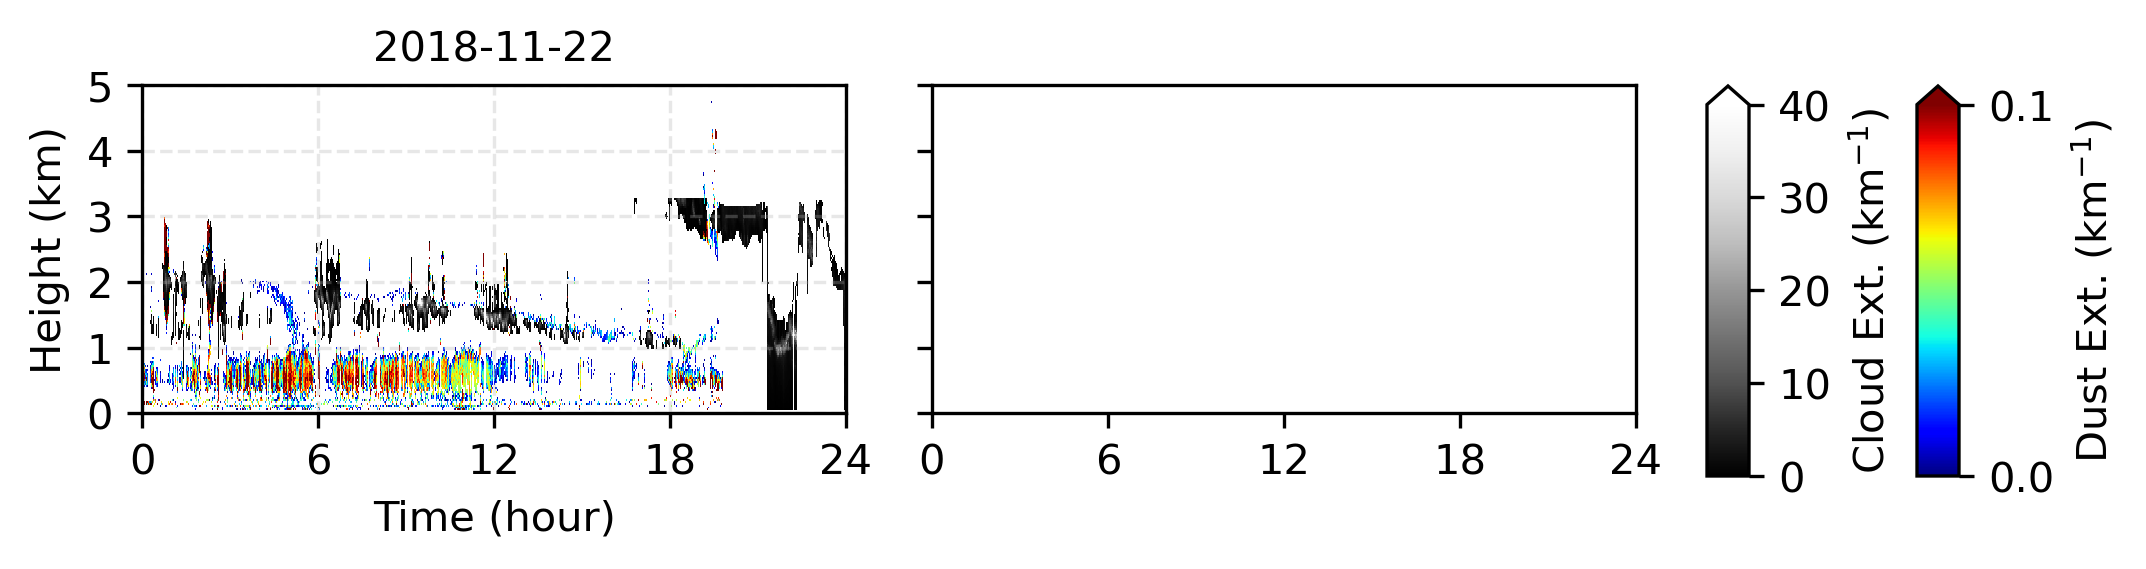

In [42]:
days = pd.DatetimeIndex(pd.to_datetime(ext_cloud.time.values)).normalize().unique()[:2]
hmin_plot, hmax_plot = 0.0, 5.0

def edges(x):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    return np.r_[x[0] - (x[1] - x[0]) / 2,
                 (x[:-1] + x[1:]) / 2,
                 x[-1] + (x[-1] - x[-2]) / 2]

z_edges = edges(ext_cloud[hcoord].values.astype(float))

fig, axes = plt.subplots(1, 2, figsize=(7, 2), sharex=True, sharey=True, dpi=300)
axes = np.atleast_1d(axes)

img_cloud = img_dust = None

for ax, day in zip(axes, days):
    t0 = pd.Timestamp(day)
    t1 = t0 + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    cloud_day = ext_cloud.sel(time=slice(t0, t1))
    dust_day  = ext_dust.sel(time=slice(t0, t1))
    cloud_day, dust_day = xr.align(cloud_day, dust_day, join="outer")

    if cloud_day.time.size < 2:
        ax.set_visible(False)
        continue

    t = pd.DatetimeIndex(pd.to_datetime(cloud_day.time.values))
    hours = (t - t.normalize()).total_seconds() / 3600.0
    x_edges = edges(hours)

    Zc = cloud_day.transpose("time", hcoord).values.T
    Zd = dust_day.transpose("time", hcoord).values.T

    img_cloud = ax.pcolormesh(
        x_edges, z_edges, Zc,
        cmap="Greys_r", shading="auto",
        vmin=0, vmax=40, alpha=1
    )

    img_dust = ax.pcolormesh(
        x_edges, z_edges, Zd,
        cmap="jet", 
        vmin=0, vmax=0.1, alpha=1
    )

    ax.set_xlim(0, 24)
    ax.set_ylim(hmin_plot, hmax_plot)
    ax.set_xticks(np.arange(0, 25, 6))
    ax.set_yticks(np.arange(0, 6, 1))
    ax.set_xlabel("Time (hour)")
    ax.set_title(pd.Timestamp(day).strftime("%Y-%m-%d"), fontsize=10)
    ax.grid(ls='--',zorder=0,alpha=0.3)
axes[0].set_ylabel("Height (km)")

fig.subplots_adjust(right=0.82)

cax1 = fig.add_axes([0.82, 0.18, 0.02, 0.65])
cax2 = fig.add_axes([0.92, 0.18, 0.02, 0.65])

if img_cloud is not None:
    cb1 = fig.colorbar(img_cloud, cax=cax1, extend="max")
    cb1.set_label("Cloud Ext. (km$^{-1}$)")

if img_dust is not None:
    cb2 = fig.colorbar(img_dust, cax=cax2, extend="max")
    cb2.set_label("Dust Ext. (km$^{-1}$)")
    cb2.set_ticks([0, 0.1])

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig("figsave/ENA_example20181122.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [46]:
data_dir = "/data/shared_data/ARM_data/ENA/enarlproffex1thorC1"

dates = ["20220202", ]   # change to the day you want

files = []
for d in dates:
    f = glob.glob(f"{data_dir}/enarlproffex1thorC1.c0.{d}*.nc")
    files.extend(f)

print(files)

if len(files) == 0:
    raise FileNotFoundError("No files found. Check date or filename pattern.")

# ds_a = xr.open_mfdataset(files, combine="by_coords")
ds_a = xr.open_mfdataset(
    files,
    combine="by_coords",
    compat="override"
)

['/data/shared_data/ARM_data/ENA/enarlproffex1thorC1/enarlproffex1thorC1.c0.20220202.000000.custom.nc']


In [47]:
# ===== parameters =====
hcoord = "height_high"
hmin_km, hmax_km = 0.03, 20.0

valid_classes = [3, 9, 21, 37]
aerosol_class = 3
cloud_class = 21

dep_m  = 0.0049
dep_d  = 0.31
dep_nd = 0.15
T_K_WARM = 273.15

ds_sub = ds_a.sel({hcoord: slice(hmin_km, hmax_km)})

# ===== QC =====
mask_qc = (
    (ds_sub["detection_confidence_score_total"] >= 0.3) &
    (ds_sub["qc_profile"] == 0)
)

feature_mask = ds_sub["feature_mask"].where(mask_qc)
pdr_meas     = ds_sub["depolarization_ratio"].where(mask_qc)
ext          = ds_sub["extinction_be"].where(mask_qc)
sca          = ds_sub["scattering_ratio_e"].where(mask_qc)
temp_qc      = ds_sub["temperature"].where(mask_qc)

# ===== keep valid classes =====
mask_class = xr.zeros_like(feature_mask, dtype=bool)
for val in valid_classes:
    mask_class = mask_class | (feature_mask == val)

feature_mask = feature_mask.where(mask_class)
pdr_meas     = pdr_meas.where(mask_class)
ext          = ext.where(mask_class)
sca          = sca.where(mask_class)
temp_qc      = temp_qc.where(mask_class)

# ===== aerosol extinction =====
aerosol_mask = feature_mask == aerosol_class

pdr_meas_aerosol = pdr_meas.where(aerosol_mask)
sca_aerosol      = sca.where(aerosol_mask)
ext_aerosol      = ext.where(aerosol_mask)

# ===== cloud extinction: warm cloud only =====
cloud_mask_warm = (feature_mask == cloud_class) & (temp_qc >= T_K_WARM)

ext_cloud = ext.where(cloud_mask_warm)
ext_cloud = ext_cloud.where(ext_cloud > 0)

# ===== calculate PDR =====
tepo = sca_aerosol + (sca_aerosol * dep_m) - dep_m
xnum = tepo * pdr_meas_aerosol - dep_m
xden = sca_aerosol - 1 + (sca_aerosol * dep_m) - pdr_meas_aerosol

pdr = xnum / xden

# ===== dust fraction =====
dust_frac = ((pdr - dep_nd) * (1 + dep_d)) / ((dep_d - dep_nd) * (1 + pdr))
dust_frac = dust_frac.where(pdr < dep_d, 1.0)
dust_frac = dust_frac.where(pdr > dep_nd, 0.0)
dust_frac = dust_frac.where(aerosol_mask)

# ===== dust extinction =====
ext_dust = (dust_frac * ext_aerosol).where(lambda v: v > 0)

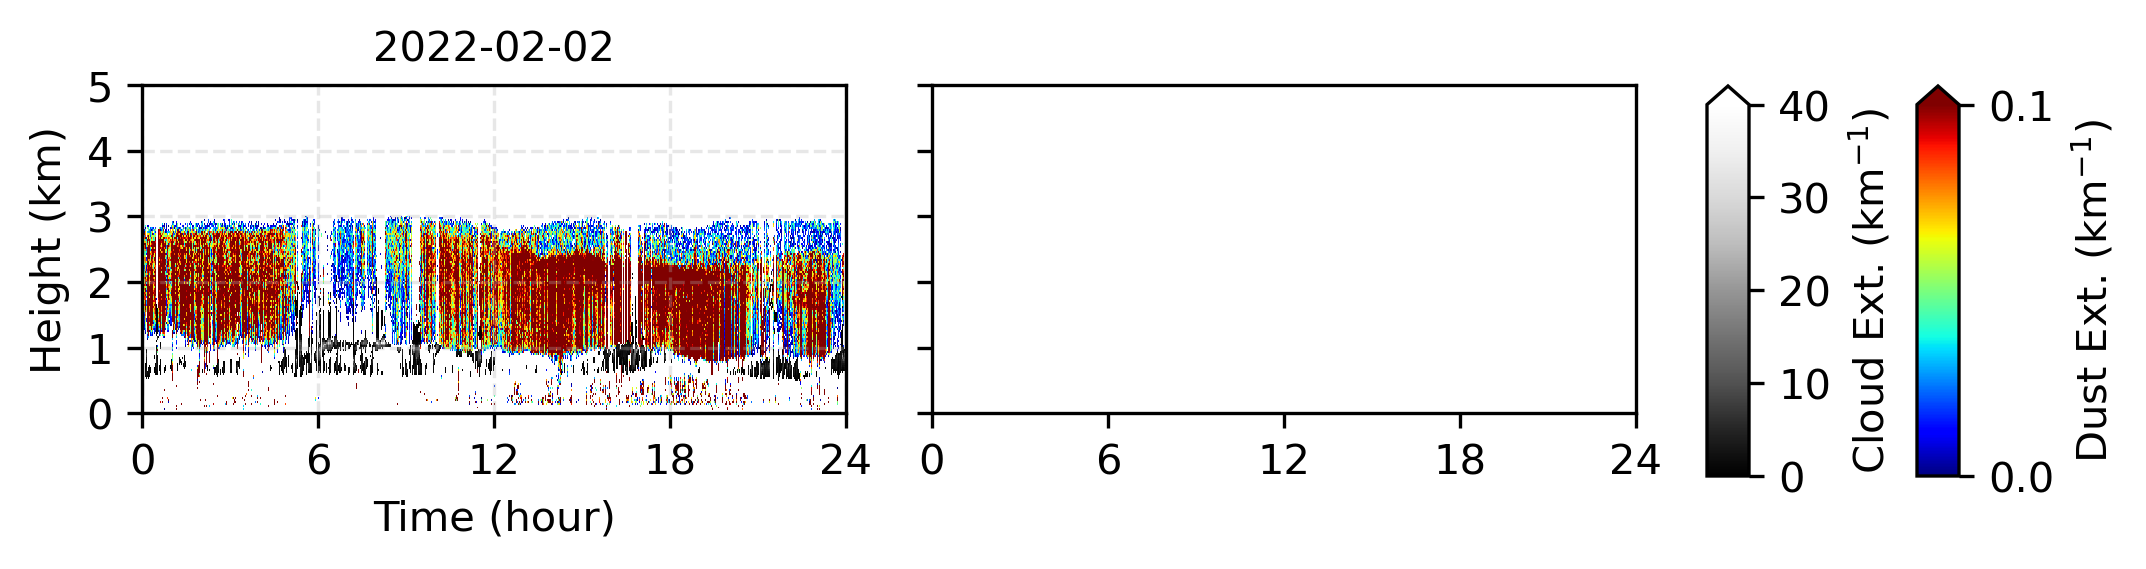

In [50]:
days = pd.DatetimeIndex(pd.to_datetime(ext_cloud.time.values)).normalize().unique()[:2]
hmin_plot, hmax_plot = 0.0, 5.0

def edges(x):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    return np.r_[x[0] - (x[1] - x[0]) / 2,
                 (x[:-1] + x[1:]) / 2,
                 x[-1] + (x[-1] - x[-2]) / 2]

z_edges = edges(ext_cloud[hcoord].values.astype(float))

fig, axes = plt.subplots(1, 2, figsize=(7, 2), sharex=True, sharey=True, dpi=300)
axes = np.atleast_1d(axes)

img_cloud = img_dust = None

for ax, day in zip(axes, days):
    t0 = pd.Timestamp(day)
    t1 = t0 + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    cloud_day = ext_cloud.sel(time=slice(t0, t1))
    dust_day  = ext_dust.sel(time=slice(t0, t1))
    cloud_day, dust_day = xr.align(cloud_day, dust_day, join="outer")

    if cloud_day.time.size < 2:
        ax.set_visible(False)
        continue

    t = pd.DatetimeIndex(pd.to_datetime(cloud_day.time.values))
    hours = (t - t.normalize()).total_seconds() / 3600.0
    x_edges = edges(hours)

    Zc = cloud_day.transpose("time", hcoord).values.T
    Zd = dust_day.transpose("time", hcoord).values.T

    img_cloud = ax.pcolormesh(
        x_edges, z_edges, Zc,
        cmap="Greys_r", shading="auto",
        vmin=0, vmax=40, alpha=1
    )

    img_dust = ax.pcolormesh(
        x_edges, z_edges, Zd,
        cmap="jet", 
        vmin=0, vmax=0.1, alpha=1
    )

    ax.set_xlim(0, 24)
    ax.set_ylim(hmin_plot, hmax_plot)
    ax.set_xticks(np.arange(0, 25, 6))
    ax.set_yticks(np.arange(0, 6, 1))
    ax.set_xlabel("Time (hour)")
    ax.set_title(pd.Timestamp(day).strftime("%Y-%m-%d"), fontsize=10)
    ax.grid(ls='--',zorder=0,alpha=0.3)
axes[0].set_ylabel("Height (km)")

fig.subplots_adjust(right=0.82)

cax1 = fig.add_axes([0.82, 0.18, 0.02, 0.65])
cax2 = fig.add_axes([0.92, 0.18, 0.02, 0.65])

if img_cloud is not None:
    cb1 = fig.colorbar(img_cloud, cax=cax1, extend="max")
    cb1.set_label("Cloud Ext. (km$^{-1}$)")

if img_dust is not None:
    cb2 = fig.colorbar(img_dust, cax=cax2, extend="max")
    cb2.set_label("Dust Ext. (km$^{-1}$)")
    cb2.set_ticks([0, 0.1])

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig("figsave/ENA_example20220202.pdf", dpi=300, bbox_inches='tight')
plt.show()

# SGP

In [43]:
data_dir = "/data/shared_data/ARM_data/SGP/sgprlproffex1thorC1"

dates = ["20160223", "20220530"]   # change to the day you want

files = []
for d in dates:
    f = glob.glob(f"{data_dir}/sgprlproffex1thorC1.c0.{d}.000000.nc")
    files.extend(f)

print(files)

if len(files) == 0:
    raise FileNotFoundError("No files found. Check date or filename pattern.")

ds_a = xr.open_mfdataset(files, combine="by_coords")

['/data/shared_data/ARM_data/SGP/sgprlproffex1thorC1/sgprlproffex1thorC1.c0.20160223.000000.nc', '/data/shared_data/ARM_data/SGP/sgprlproffex1thorC1/sgprlproffex1thorC1.c0.20220530.000000.nc']


In [44]:
# ===== parameters =====
hcoord = "height_high"
hmin_km, hmax_km = 0.03, 20.0

valid_classes = [3, 9, 21, 37]
aerosol_class = 3
cloud_class = 21

dep_m  = 0.0049
dep_d  = 0.31
dep_nd = 0.15
T_K_WARM = 273.15

ds_sub = ds_a.sel({hcoord: slice(hmin_km, hmax_km)})

# ===== QC =====
mask_qc = (
    (ds_sub["detection_confidence_score_total"] >= 0.3) &
    (ds_sub["qc_profile"] == 0)
)

feature_mask = ds_sub["feature_mask"].where(mask_qc)
pdr_meas     = ds_sub["depolarization_ratio"].where(mask_qc)
ext          = ds_sub["extinction_be"].where(mask_qc)
sca          = ds_sub["scattering_ratio_e"].where(mask_qc)
temp_qc      = ds_sub["temperature"].where(mask_qc)

# ===== keep valid classes =====
mask_class = xr.zeros_like(feature_mask, dtype=bool)
for val in valid_classes:
    mask_class = mask_class | (feature_mask == val)

feature_mask = feature_mask.where(mask_class)
pdr_meas     = pdr_meas.where(mask_class)
ext          = ext.where(mask_class)
sca          = sca.where(mask_class)
temp_qc      = temp_qc.where(mask_class)

# ===== aerosol extinction =====
aerosol_mask = feature_mask == aerosol_class

pdr_meas_aerosol = pdr_meas.where(aerosol_mask)
sca_aerosol      = sca.where(aerosol_mask)
ext_aerosol      = ext.where(aerosol_mask)

# ===== cloud extinction: warm cloud only =====
cloud_mask_warm = (feature_mask == cloud_class) & (temp_qc >= T_K_WARM)

ext_cloud = ext.where(cloud_mask_warm)
ext_cloud = ext_cloud.where(ext_cloud > 0)

# ===== calculate PDR =====
tepo = sca_aerosol + (sca_aerosol * dep_m) - dep_m
xnum = tepo * pdr_meas_aerosol - dep_m
xden = sca_aerosol - 1 + (sca_aerosol * dep_m) - pdr_meas_aerosol

pdr = xnum / xden

# ===== dust fraction =====
dust_frac = ((pdr - dep_nd) * (1 + dep_d)) / ((dep_d - dep_nd) * (1 + pdr))
dust_frac = dust_frac.where(pdr < dep_d, 1.0)
dust_frac = dust_frac.where(pdr > dep_nd, 0.0)
dust_frac = dust_frac.where(aerosol_mask)

# ===== dust extinction =====
ext_dust = (dust_frac * ext_aerosol).where(lambda v: v > 0)

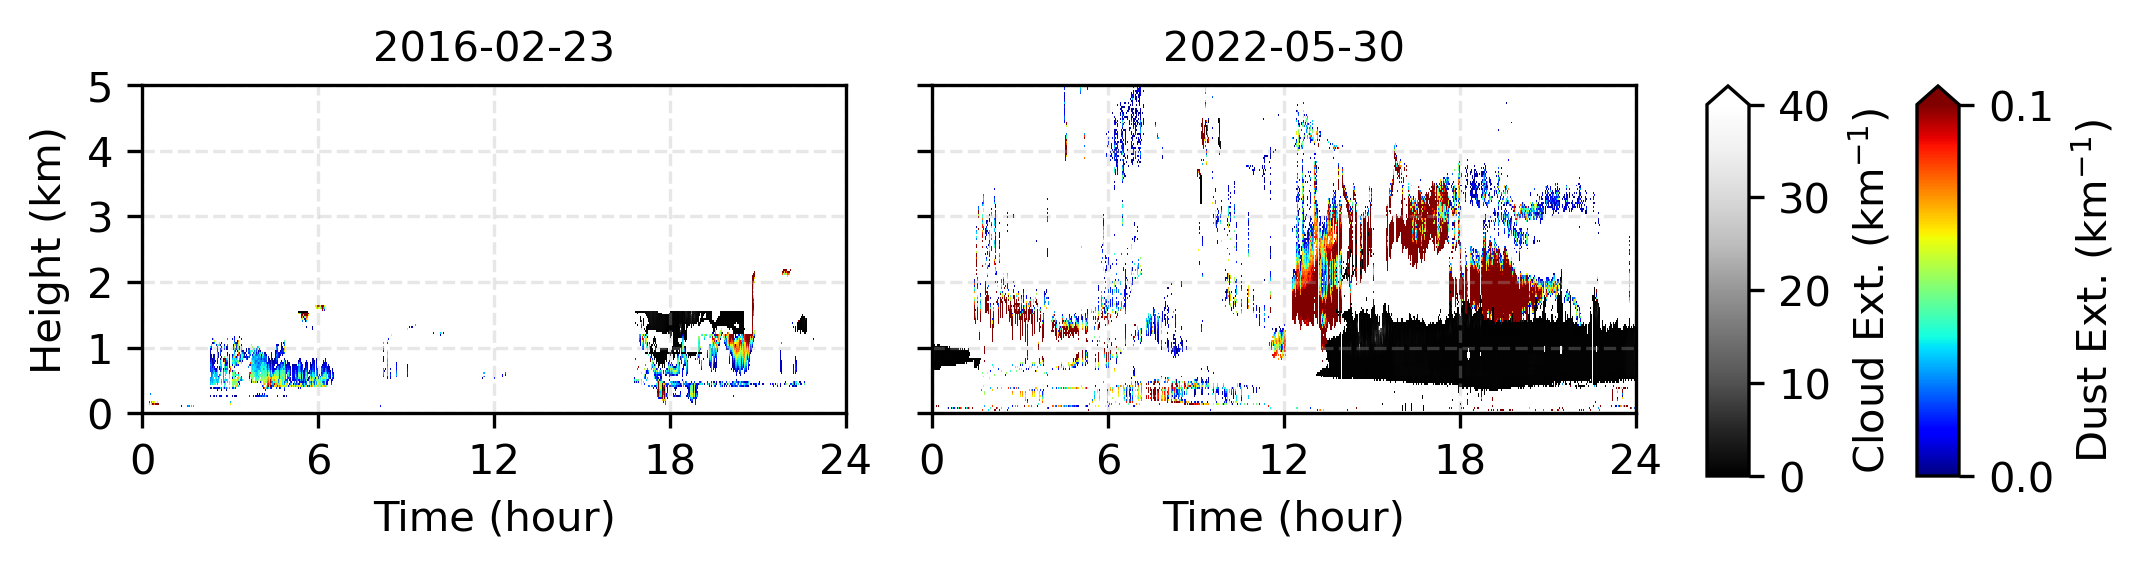

In [45]:
days = pd.DatetimeIndex(pd.to_datetime(ext_cloud.time.values)).normalize().unique()[:2]
hmin_plot, hmax_plot = 0.0, 5.0

def edges(x):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    return np.r_[x[0] - (x[1] - x[0]) / 2,
                 (x[:-1] + x[1:]) / 2,
                 x[-1] + (x[-1] - x[-2]) / 2]

z_edges = edges(ext_cloud[hcoord].values.astype(float))

fig, axes = plt.subplots(1, 2, figsize=(7, 2), sharex=True, sharey=True, dpi=300)
axes = np.atleast_1d(axes)

img_cloud = img_dust = None

for ax, day in zip(axes, days):
    t0 = pd.Timestamp(day)
    t1 = t0 + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    cloud_day = ext_cloud.sel(time=slice(t0, t1))
    dust_day  = ext_dust.sel(time=slice(t0, t1))
    cloud_day, dust_day = xr.align(cloud_day, dust_day, join="outer")

    if cloud_day.time.size < 2:
        ax.set_visible(False)
        continue

    t = pd.DatetimeIndex(pd.to_datetime(cloud_day.time.values))
    hours = (t - t.normalize()).total_seconds() / 3600.0
    x_edges = edges(hours)

    Zc = cloud_day.transpose("time", hcoord).values.T
    Zd = dust_day.transpose("time", hcoord).values.T

    img_cloud = ax.pcolormesh(
        x_edges, z_edges, Zc,
        cmap="Greys_r", shading="auto",
        vmin=0, vmax=40, alpha=1
    )

    img_dust = ax.pcolormesh(
        x_edges, z_edges, Zd,
        cmap="jet", 
        vmin=0, vmax=0.1, alpha=1
    )

    ax.set_xlim(0, 24)
    ax.set_ylim(hmin_plot, hmax_plot)
    ax.set_xticks(np.arange(0, 25, 6))
    ax.set_yticks(np.arange(0, 6, 1))
    ax.set_xlabel("Time (hour)")
    ax.set_title(pd.Timestamp(day).strftime("%Y-%m-%d"), fontsize=10)
    ax.grid(ls='--',zorder=0,alpha=0.3)
axes[0].set_ylabel("Height (km)")

fig.subplots_adjust(right=0.82)

cax1 = fig.add_axes([0.82, 0.18, 0.02, 0.65])
cax2 = fig.add_axes([0.92, 0.18, 0.02, 0.65])

if img_cloud is not None:
    cb1 = fig.colorbar(img_cloud, cax=cax1, extend="max")
    cb1.set_label("Cloud Ext. (km$^{-1}$)")

if img_dust is not None:
    cb2 = fig.colorbar(img_dust, cax=cax2, extend="max")
    cb2.set_label("Dust Ext. (km$^{-1}$)")
    cb2.set_ticks([0, 0.1])

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig("figsave/SGP_example.pdf", dpi=300, bbox_inches='tight')
plt.show()